In [1]:
import numpy as np
import pandas as pd
import your
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import matplotlib as mpl
from matplotlib import colors
from scipy.optimize import curve_fit, leastsq, minimize_scalar
import numpy.ma as ma
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from astropy.time import Time
from typing import Union, List
from scipy.signal import find_peaks
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

import frb_functions

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

In [2]:
def masked_percentile(arr, q):
    return np.percentile(arr.compressed(), q)

In [3]:
def load_burst_wb(burst,burst_tstamp, downsamp_t=1,downsamp_f=1):

    print("#############")
    print("## Loading Westerbork ##")
    print("#############")
    
    burst = your.Your(burst)

    header_dict = frb_functions.your_header_to_dict(burst)
    tsamp = header_dict["tsamp"]
    nbins = header_dict["nspectra"]
    fsamp = header_dict["foff"] * -1
    freqs = header_dict["freqs"] # in Mhz
    
    tmin = 0.0
    tmax = nbins * burst.tsamp # seconds
    fmin = header_dict["fmin"]
    fmax = header_dict["fmax"]
    extent_b = [tmin, tmax, fmin, fmax]

    offset = burst_tstamp #
    extent_b[0] = (tmin - offset) * 1000
    extent_b[1] = (tmax - offset) * 1000
    print(f"the extent of the data is: {extent_b}")
    
    #time increasing, freq decreasing
    print("loading in the data")
    d = frb_functions.get_data(burst, nstart=0, nsamp=nbins, npoln=1)

    sides_bandpass = 'right' 
    scale_bandpass = 3

    #Correcting the bandpass
    stokes_i = frb_functions.correct_bandpass(d, sides=sides_bandpass, scale=scale_bandpass)

    #Masking the subband edges en correcting for the bandpass again
    bandwidth = header_dict["bw"] * - 1
    nchans = header_dict["nchans"]
    band_edges = frb_functions.get_subband_edges(bandwidth, nchans)
    stokes_i = frb_functions.mask_array(array=stokes_i, bad_chan_idx=band_edges)

    #Correcting the bandpass
    print(f"Correcting the bandpass")
    stokes_i = frb_functions.correct_bandpass(stokes_i, sides=sides_bandpass, scale=scale_bandpass)
    
    print(f"downsample factors are: time:{downsamp_t} and freq:{downsamp_f}")
    if downsamp_f > 1 or downsamp_t > 1:
        print(f"running downsampling and correcting bandpass")
        stokes_i = frb_functions.downsample(stokes_i, freqf=downsamp_f, timef=downsamp_t)
        tsamp = tsamp * downsamp_t
        fsamp = fsamp * downsamp_f
        stokes_i = frb_functions.correct_bandpass(stokes_i, sides=sides_bandpass, scale=scale_bandpass)
        downsamp_flag = True
    else:
        downsamp_flag = False

    #Create x grid to plot the step function. 
    x_grid = np.linspace(extent_b[0], extent_b[1], endpoint=False, num=stokes_i.shape[1])

    prof = np.ma.mean(stokes_i,axis=0)
    stokes_i_normprof = frb_functions.normalize_1d(prof, sides=sides_bandpass, scale=scale_bandpass)

    new_quantiles = masked_percentile(stokes_i, (1.0, 99.7))
    #new_quantiles = np.nanpercentile(stokes_i, (0.01, 99.99))

    return stokes_i, stokes_i_normprof, x_grid, new_quantiles, extent_b, tsamp, fsamp

#############
## Loading Westerbork ##
#############
the extent of the data is: [-1085.0, 1730.9999999999998, 1207.0, 1335.0]
loading in the data
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32
Correcting the bandpass
downsample factors are: time:1 and freq:1
#############
## Loading Westerbork ##
#############
the extent of the data is: [-814.0, 2001.9999999999998, 1380.0, 1508.0]
loading in the data
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32
Correcting the bandpass
downsample factors are: time:1 and freq:1
#############
## Making Plot ##
#############
The burst is: B137-Wb
    The time resolution is: 16 microseconds
    The frequency resolution is: 500 kHz
The burst is: B137-Tr
    The time resolution is: 16 microseconds
    The frequency resolution is: 500 kHz


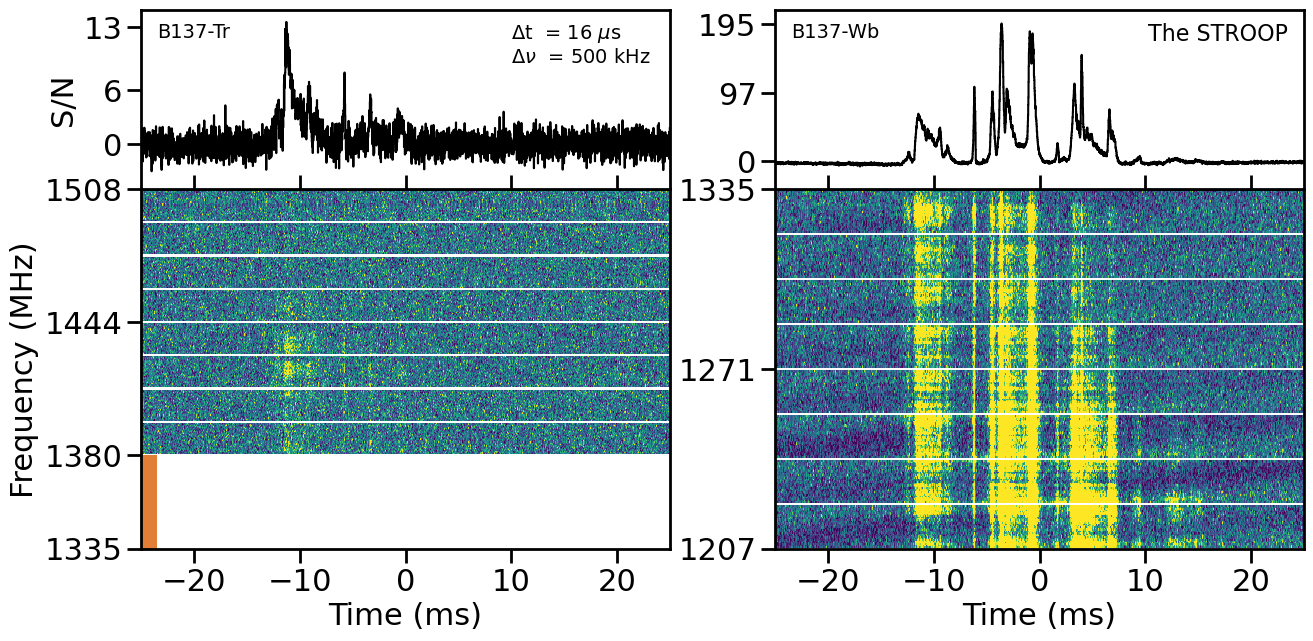

In [11]:
def waterfaller_dm():
    """
    NRT WB
    ax1 ax2 -- time series
    ax3 ax4 -- dynamic spectra   
    """
    
    ###################################
    #DM -- 528.47 - already applied to both
    #Loading in the bursts
    ##### Wb ######
    #burst_dat_wb = "/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_1us_500KHz_StokesI_DM5284.cor_Wb.fil"
    burst_dat_wb = "/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_16us_500KHz_StokesI_DM5284.cor_Wb.fil"
    #burst_dat_wb = "/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_32us_500KHz_StokesI_DM5284.cor_Wb.fil"
    wb_burst_tstamp = 1.085
    stokes_i_wb, stokes_i_normprof_wb, x_grid_wb, new_quantiles_wb, extent_b_wb, tsamp_wb, fsamp_wb = load_burst_wb(burst = burst_dat_wb,\
                                                                                                      burst_tstamp = wb_burst_tstamp,\
                                                                                                      downsamp_t=1, downsamp_f=1)

    ##### Tr  ######
    burst_dat_tr = "/data1/omar/sfxc/frb240114a/rn1l40_17_tr_60586.95300/rn1l40_17_16us_500KHz_StokesI_DM52847.cor_Tr.fil"
    #burst_dat_tr = "/data1/omar/sfxc/frb240114a/rn1l40_17_tr_60586.95300/rn1l40_17_1us_500KHz_StokesI_DM52847.cor_Tr.fil"
    tr_burst_tstamp = 0.814
    stokes_i_tr, stokes_i_normprof_tr, x_grid_tr, new_quantiles_tr, extent_b_tr, tsamp_tr, fsamp_tr = load_burst_wb(burst = burst_dat_tr,\
                                                                                                      burst_tstamp = tr_burst_tstamp,\
                                                                                                      downsamp_t=1, downsamp_f=1)

    print("#############")
    print("## Making Plot ##")
    print("#############")    
    ###################################
    #Define the figure
    fig5 = plt.figure(figsize=(15,7))
    
    #Width 0.1 is for the hidden axes
    widths = [1, 1]
    heights = [1, 2]
    spec5 = fig5.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights, wspace=0.2, hspace=0.0)

    ###################################
    #Drawing the dynamic spectra
    #ax3
    ax3 = fig5.add_subplot(spec5[1, 1])
    ax3.imshow(stokes_i_wb, aspect='auto', interpolation='None',\
          extent=extent_b_wb, vmin=new_quantiles_wb[0], vmax=new_quantiles_wb[1])
    window_ms = 25
    ax3.set_xlim(-window_ms,window_ms)
    ax3.set_xlabel('Time (ms)',size=22)
    ax3.set_yticks([1335, 1271, 1207])
    ax3.set_yticklabels([1335, 1271, 1207])

    #ax4
    ax4 = fig5.add_subplot(spec5[1, 0])
    ax4.set_xlabel('Time (ms)',size=22)
    
    ax4.imshow(stokes_i_tr, aspect='auto', interpolation='None',\
          extent=extent_b_tr, vmin=new_quantiles_tr[0], vmax=new_quantiles_tr[1])
    window_ms = 25
    ax4.set_ylabel('Frequency (MHz)',size=22)
    ax4.set_xlim(-window_ms,window_ms)
    #Manually setting the ylim extent, 
    ax4.set_ylim(1335,extent_b_tr[3])
    ax4.set_yticks([1335, 1380, 1444, 1508])
    ax4.set_yticklabels([1335, 1380, 1444, 1508])

    # Place a narrow red bar on the left edge inside ax4, spanning the gap in frequency
    gap_bar = Rectangle(
        (-25, 1335),        # (x_start, y_start) — left edge of your xlim
        1.5,                  # width in ms — adjust to taste
        1380 - 1335,        # height in MHz
        linewidth=0,
        facecolor='#d95f02',
        alpha=0.8,
        zorder=0            # below everything
    )
    ax4.add_patch(gap_bar)

    ###################################
    #Drawing the time series
    #ax1
    ax1 = fig5.add_subplot(spec5[0, 1], sharex=ax3)
    ax1.plot(x_grid_wb, stokes_i_normprof_wb, drawstyle='steps-post', color='black') 
    
    #Ticks on the SN-
    maxSN = np.max(stokes_i_normprof_wb)
    yticks_sn=np.array([0,int(maxSN/2),int(maxSN)])
    ax1.set_yticks(yticks_sn)
    window_sn = 1.1 * maxSN
    minSN = -40
    ax1.set_ylim(minSN,window_sn)
    ax1.text(0.03, 0.93, "B137-Wb", transform=ax1.transAxes, fontsize=14, va='top', ha='left')
    ax1.text(0.97, 0.93, "The STROOP", transform=ax1.transAxes, fontsize=16, va='top', ha='right')
    print(f"""The burst is: B137-Wb
    The time resolution is: {(tsamp_wb*1e6):.0f} microseconds
    The frequency resolution is: {(fsamp_wb*1e3):.0f} kHz""")
    
    #ax2
    ax2 = fig5.add_subplot(spec5[0, 0], sharex=ax4)
    ax2.set_ylabel('S/N',size=22)
    ax2.plot(x_grid_tr, stokes_i_normprof_tr, drawstyle='steps-post', color='black')
    maxSN = np.max(stokes_i_normprof_tr)
    window_sn = 1.1 * maxSN
    minSN = -5
    yticks_sn=np.array([0,int(maxSN/2),int(maxSN)])
    ax2.set_yticks(yticks_sn)
    ax2.set_ylim(minSN,window_sn)    
    ax2.text(0.70, 0.93, fr"$\Delta$t  = {(tsamp_tr*1e6):.0f} $\mu$s" + "\n" + fr"$\Delta \nu$  = {(fsamp_tr*1e3):.0f} kHz ",\
             transform=ax2.transAxes, fontsize=14, va='top', ha='left')
    ax2.text(0.03, 0.93, "B137-Tr", transform=ax2.transAxes, fontsize=14, va='top', ha='left')
    print(f"""The burst is: B137-Tr
    The time resolution is: {(tsamp_tr*1e6):.0f} microseconds
    The frequency resolution is: {(fsamp_tr*1e3):.0f} kHz""")
    
    ###################################
    #Settings for the plot
    for ax in [ax1,ax2,ax3,ax4]:
        
        ax.tick_params(labelsize=22) 
        
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2)

            ax.tick_params(axis='y', which='major', direction='out', length=10, width=2)
            ax.tick_params(axis='y', which='minor', direction='out', length=5, width=2)
            ax.tick_params(axis='x', which='major', direction='out', length=10, width=2)
            ax.tick_params(axis='x', which='minor', direction='out', length=5, width=2)
    
    for ax in [ax1, ax2]:
        
        ax.tick_params(labelbottom=False)
        ax.tick_params(axis='x', which='major', direction='in', length=10, width=2)
        ax.tick_params(axis='x', which='minor', direction='in', length=5, width=2)

    ###################################
    #Saving the plot
    plot_name = "the_stroop_v4"

    plt.show()
    fig5.savefig(f"../plots/{plot_name}" + ".pdf", dpi=300, bbox_inches='tight')
    
    fig5.savefig(f"../plots/{plot_name}" + ".png", facecolor='white', \
           transparent=False, format = 'png',bbox_inches='tight', dpi=300)
    
    return

waterfaller_dm()